# Лабораторная 7
## Методы последовательной безусловной минимизации
### Задачи
1) Реализовать метод внутренних штрафных (барьерных) функций, метод внешних штрафных функций.
2) Решить предложенные задачи минимизации функции Розенброка с ограничениями и показать, что программы работают корректно.
3) Построить графики

### Минимизируем методом сопряженных градиентов Флетчера-Ривса с золотым сечением

In [1]:
import numpy as np

# золотое сечение
def bracket_minimum(phi, x, p, step=0.01):
    a = 0
    b = step

    phi_calls = 0

    fa = phi(x, a, p)
    fb = phi(x, b, p)
    phi_calls += 2

    if fa < fb:
        return a, b, phi_calls

    while True:
        step *= 2
        c = b + step
        fc = phi(x, c, p)
        phi_calls += 1

        if fb < fc:
            return a, c, phi_calls

        a = b
        b = c
        fb = fc

def golden_ratio(phi, x, p, eps=1e-6):
    a, b, phi_calls = bracket_minimum(phi, x, p)

    t = (np.sqrt(5) - 1) / 2

    x1 = b - t*(b-a)
    x2 = a + t*(b-a)

    y1 = phi(x, x1, p)
    y2 = phi(x, x2, p)

    phi_calls += 2

    while abs(b-a) > eps:

        if y1 < y2:
            b = x2
            x2 = x1
            y2 = y1
            x1 = b - t*(b-a)
            y1 = phi(x, x1, p)
        else:
            a = x1
            x1 = x2
            y1 = y2
            x2 = a + t*(b-a)
            y2 = phi(x, x2, p)

        phi_calls += 1

    return (a+b)/2, phi_calls

# сопряженные градиенты
def conjugate_gradient_method(func, func_grad, gamma_func, x0, alpha_func=None, hess_func=None, eps=1e-4):

    x = np.array(x0, dtype=float)

    phi = lambda x, a, p: func(x[0] + a*p[0], x[1] + a*p[1])

    points = [x.copy()]
    grad_norms = []

    iterations = 0
    calls = 0

    grad = func_grad(x[0], x[1])
    calls += 1

    p = -grad
    grad_norms.append(np.linalg.norm(grad))

    while grad_norms[-1] > eps:
        
        if alpha_func is None:
            alpha, phi_calls = golden_ratio(phi, x, p)
            calls += phi_calls
        else:
            alpha = alpha_func(x, grad, p)

        x_new = x + alpha * p
        points.append(x_new.copy())

        grad_new = func_grad(x_new[0], x_new[1])
        calls += 1

        grad_norms.append(np.linalg.norm(grad_new))
        
        if hess_func is None:
            gamma = gamma_func(grad_new, grad, p)
        else:
            gamma = gamma_func(grad_new, grad, p, hess_func, x_new)

        p = -grad_new + gamma * p

        x = x_new
        grad = grad_new

        iterations += 1

    return x, iterations, calls, np.array(points), np.array(grad_norms)


def gamma_fletcher(g_new, g_old, p):
    norm_old_sq = np.dot(g_old, g_old)
    if norm_old_sq < 1e-10:
        return 0
    return np.dot(g_new, g_new) / norm_old_sq

### Методы внутренних штрафов и внешних штрафов

In [2]:
# Целевая функция Розенброка
def rosenbrock(x, y):
    return (x**2 - y)**2 + (x - 1)**2


def rosenbrock_grad(x, y):
    return np.array([
        4*x*(x**2 - y) + 2*(x - 1),
        -2*(x**2 - y)
    ])

# Функция ограничения
def g(x, y):
    return 3*x**2/4 + 5*x/4 - 2 - y

def boundary(x):
    return 3*x**2/4 + 5*x/4 - 2

def grad_g(x, y):
    return np.array([
        1.5*x + 1.25,
        -1
    ])


# Метод внутренних штрафов
def barrier_method(x0, r0=1.0, beta=0.1, eps=1e-3, max_outer=20):
    x = np.array(x0, dtype=float)

    trajectory = [x.copy()]
    all_grad_norms = []

    r = r0

    for _ in range(max_outer):

        def F(x_, y_):

            gv = g(x_, y_)

            if gv >= 0:
                return np.inf

            return rosenbrock(x_, y_) - r*np.log(-gv)

        def grad_F(x_, y_):

            gv = g(x_, y_)

            grad_f = rosenbrock_grad(x_, y_)
            grad_constraint = grad_g(x_, y_)

            return grad_f - r * grad_constraint / gv

        x, _, _, points, grad_norms = conjugate_gradient_method(
            F,
            grad_F,
            gamma_fletcher,
            x,
            eps=eps
        )


        trajectory.extend(points[1:])
        all_grad_norms.extend(grad_norms)

        r *= beta

        if r < eps:
            break

    return x, np.array(trajectory), np.array(all_grad_norms)


# Метод внешних штрафов
def external_penalty_method(x0, r0=1.0, beta=10.0, eps=1e-3, max_outer=20):

    x = np.array(x0, dtype=float)

    trajectory = [x.copy()]
    all_grad_norms = []

    r = r0

    for _ in range(max_outer):

        def F(x_, y_):

            gv = g(x_, y_)

            penalty = max(0, gv)**2

            return rosenbrock(x_, y_) + r*penalty

        def grad_F(x_, y_):

            grad_f = rosenbrock_grad(x_, y_)

            gv = g(x_, y_)

            if gv <= 0:
                return grad_f

            grad_constraint = grad_g(x_, y_)

            return grad_f + 2*r*gv*grad_constraint

        x, _, _, points, grad_norms = conjugate_gradient_method(
            F,
            grad_F,
            gamma_fletcher,
            x,
            eps=eps
        )

        trajectory.extend(points[1:])
        all_grad_norms.extend(grad_norms)

        if g(x[0], x[1]) <= eps:
            break

        r *= beta

    return x, np.array(trajectory), np.array(all_grad_norms)

### Проверка на тестовом примере


# Проверка реализованных методов
## Исходные данные
### Начальная точка:
### $$X_0 = (-1.0, -2.0)$$

### Ожидаемое решение по методичке:
### $$X^* = (1, 1)$$

---

## Метод внутренних штрафных функций
### Найденная точка минимума:
### $$X_{внутр} = (0.999627, 0.999749)$$

### Значение функции Розенброка:
### $$f(X_{внутр}) = 3.836979e-07$$

### Количество точек траектории:
### $$28$$

### Ошибка относительно ожидаемого решения:
### $$\|X_{внутр} - X^*\| = 4.491979e-04$$

---

## Метод внешних штрафных функций
### Найденная точка минимума:
### $$X_{внеш} = (0.999740, 0.999163)$$

### Значение функции Розенброка:
### $$f(X_{внеш}) = 1.685402e-07$$

### Количество точек траектории:
### $$22$$

### Ошибка относительно ожидаемого решения:
### $$\|X_{внеш} - X^*\| = 8.765655e-04$$

---

## Вывод
### Оба метода успешно нашли точку минимума, близкую к теоретическому решению
### $$X^* = (1,1)$$
### что подтверждает корректность реализованных алгоритмов.

# Топографии функций и убывания норм невязки


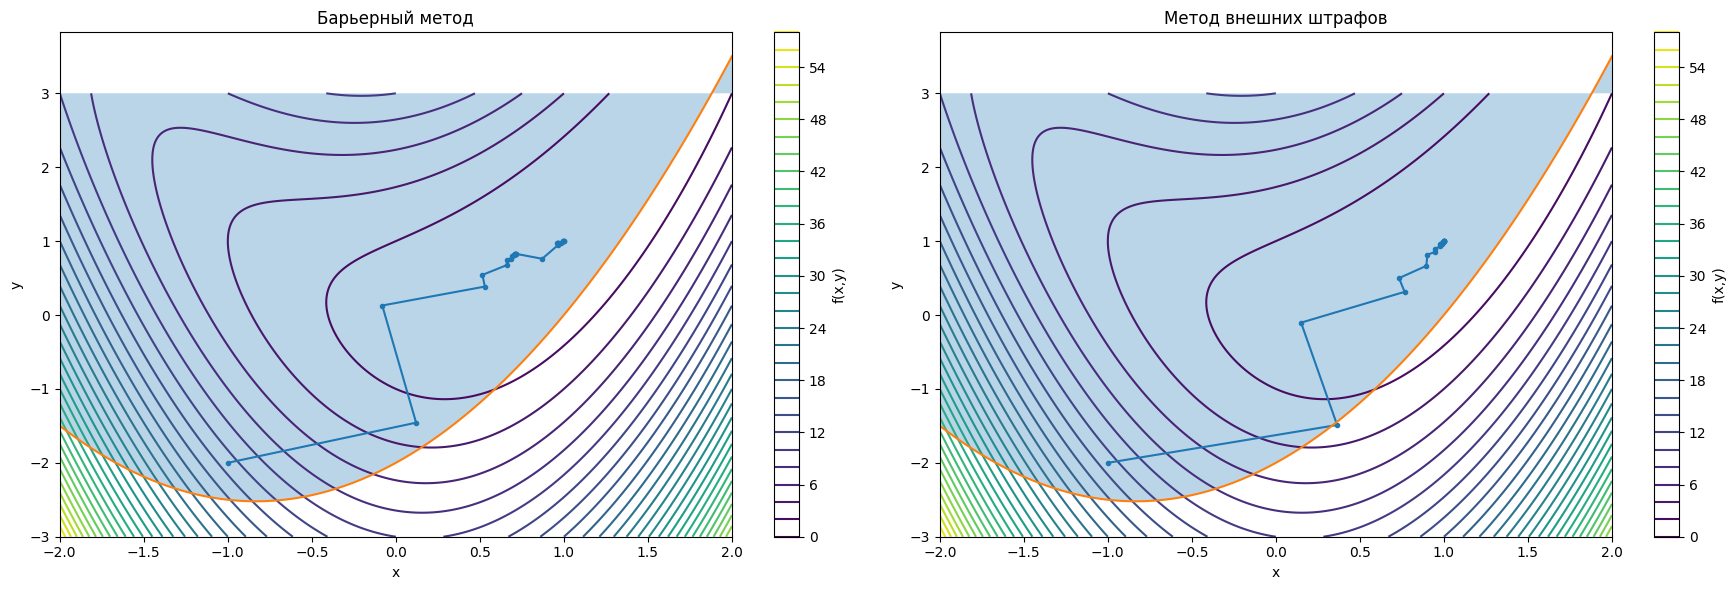

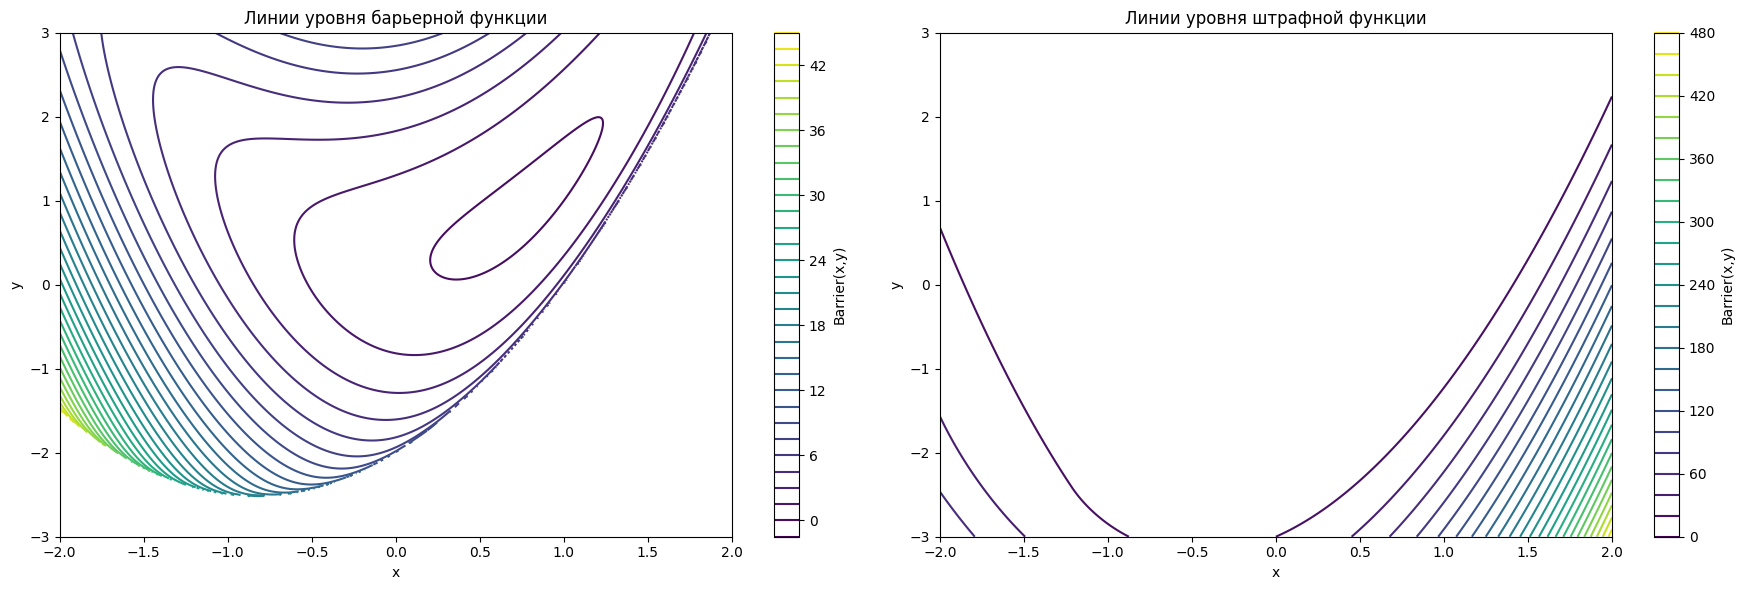

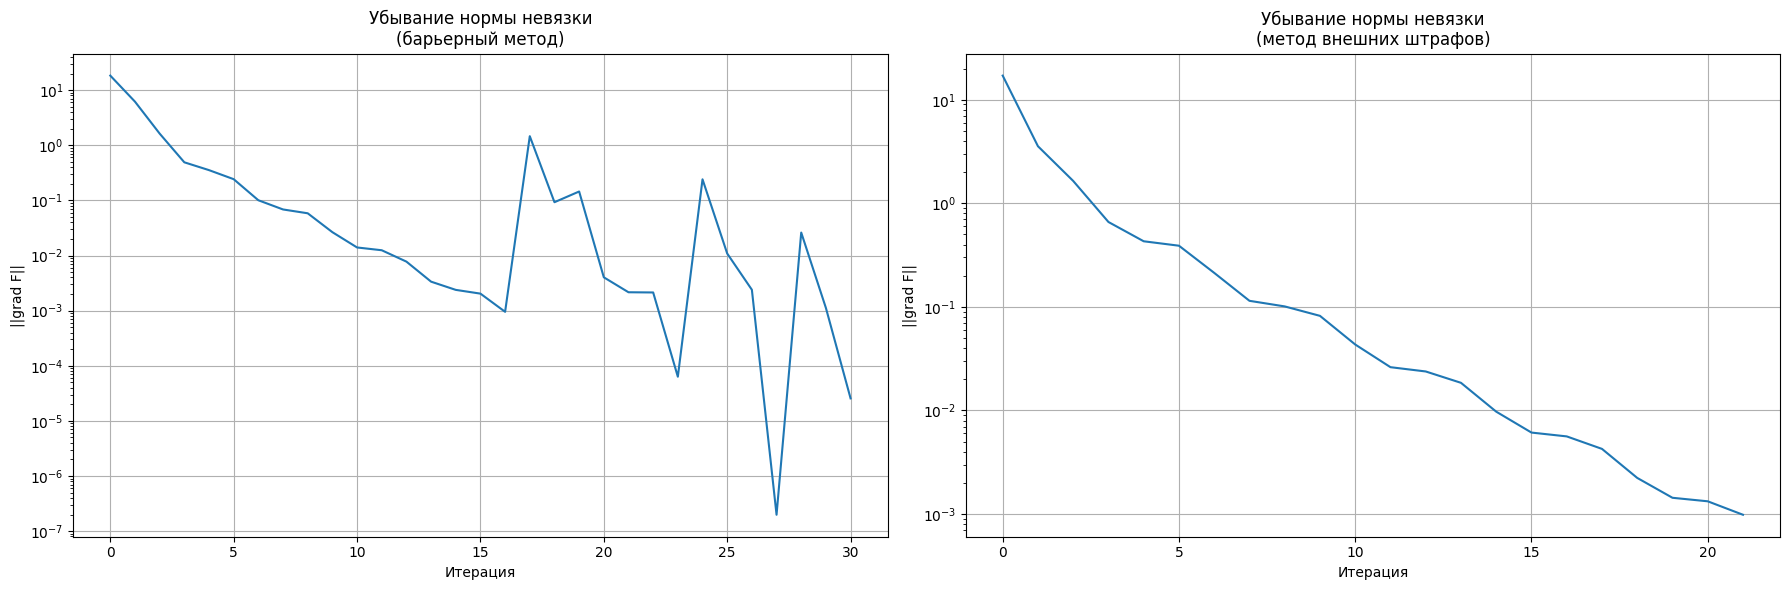

In [3]:
from IPython.display import Markdown, display

x0 = np.array([-1.0, -2.0])

xmin_barrier, traj_barrier, norms_barrier = barrier_method(x0)
xmin_penalty, traj_penalty, norms_penalty = external_penalty_method(x0)

expected = np.array([1.0, 1.0])

display(Markdown(f"""
# Проверка реализованных методов
## Исходные данные
### Начальная точка:
### $$X_0 = ({x0[0]}, {x0[1]})$$

### Ожидаемое решение по методичке:
### $$X^* = (1, 1)$$

---

## Метод внутренних штрафных функций
### Найденная точка минимума:
### $$X_{{внутр}} = ({xmin_barrier[0]:.6f}, {xmin_barrier[1]:.6f})$$

### Значение функции Розенброка:
### $$f(X_{{внутр}}) = {rosenbrock(xmin_barrier[0], xmin_barrier[1]):.6e}$$

### Количество точек траектории:
### $${len(traj_barrier)}$$

### Ошибка относительно ожидаемого решения:
### $$\\|X_{{внутр}} - X^*\\| = {np.linalg.norm(xmin_barrier - expected):.6e}$$

---

## Метод внешних штрафных функций
### Найденная точка минимума:
### $$X_{{внеш}} = ({xmin_penalty[0]:.6f}, {xmin_penalty[1]:.6f})$$

### Значение функции Розенброка:
### $$f(X_{{внеш}}) = {rosenbrock(xmin_penalty[0], xmin_penalty[1]):.6e}$$

### Количество точек траектории:
### $${len(traj_penalty)}$$

### Ошибка относительно ожидаемого решения:
### $$\\|X_{{внеш}} - X^*\\| = {np.linalg.norm(xmin_penalty - expected):.6e}$$

---

## Вывод
### Оба метода успешно нашли точку минимума, близкую к теоретическому решению
### $$X^* = (1,1)$$
### что подтверждает корректность реализованных алгоритмов.

# Топографии функций и убывания норм невязки
"""))

# Топография функций
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 400)
y = np.linspace(-3, 3, 400)

y_border = boundary(x)

X, Y = np.meshgrid(x, y)
Z = rosenbrock(X, Y)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Барьерный метод
c1 = axes[0].contour(X, Y, Z, levels=30)
fig.colorbar(c1, ax=axes[0], label="f(x,y)")

axes[0].plot(
    traj_barrier[:, 0],
    traj_barrier[:, 1],
    '-o',
    markersize=3
)

axes[0].plot(x, y_border)

axes[0].fill_between(
    x,
    y_border,
    3,
    alpha=0.3
)

axes[0].set_title("Барьерный метод")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")


# Метод внешних штрафов
c2 = axes[1].contour(X, Y, Z, levels=30)
fig.colorbar(c2, ax=axes[1], label="f(x,y)")

axes[1].plot(
    traj_penalty[:, 0],
    traj_penalty[:, 1],
    '-o',
    markersize=3
)

axes[1].plot(x, y_border)

axes[1].fill_between(
    x,
    y_border,
    3,
    alpha=0.3
)

axes[1].set_title("Метод внешних штрафов")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()

# -----------------------------

x = np.linspace(-2, 2, 400)
y = np.linspace(-3, 3, 400)

X, Y = np.meshgrid(x, y)

Z = rosenbrock(X, Y)

# Барьерная функция
r_barrier = 1

G = g(X, Y)

with np.errstate(divide='ignore', invalid='ignore'):
    Barrier = np.where(
        G < 0,
        Z - r_barrier*np.log(-G),
        np.nan
    )

# Штрафная функция
r_penalty = 10

Penalty = Z + r_penalty*np.maximum(
    0,
    G
)**2

# Общая фигура
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Барьерная функция
c1 = axes[0].contour(X, Y, Barrier, levels=30)
fig.colorbar(c1, ax=axes[0], label="Barrier(x,y)")
axes[0].set_title("Линии уровня барьерной функции")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# Штрафная функция
c2 = axes[1].contour(X, Y, Penalty, levels=30)
fig.colorbar(c2, ax=axes[1], label="Barrier(x,y)")
axes[1].set_title("Линии уровня штрафной функции")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()

# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Барьерный метод
axes[0].semilogy(norms_barrier)
axes[0].grid(True)
axes[0].set_title("Убывание нормы невязки\n(барьерный метод)")
axes[0].set_xlabel("Итерация")
axes[0].set_ylabel("||grad F||")

# Метод внешних штрафов
axes[1].semilogy(norms_penalty)
axes[1].grid(True)
axes[1].set_title("Убывание нормы невязки\n(метод внешних штрафов)")
axes[1].set_xlabel("Итерация")
axes[1].set_ylabel("||grad F||")

plt.tight_layout()
plt.show()